# Euclidean Distance to Coordinate-wise Round Trimmed Mean

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import confusion_matrix
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3"
# RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0"
BASE_PATH = Path("../experiments/shap_outputs") / RUN_NAME
BETA = 0.1  # fraction trimmed from each tail per coordinate
IQR_MULT = 1.5  # flag if distance is outside [Q1 - IQR_MULT*IQR, Q3 + IQR_MULT*IQR]

print(f"Run      : {RUN_NAME}")
print(f"Path     : {BASE_PATH}")
print(f"Beta     : {BETA}")
print(f"IQR mult : {IQR_MULT}")

Run      : fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0
Path     : ../experiments/shap_outputs/fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0
Beta     : 0.1
IQR mult : 1.5


In [2]:
# ── Loaders & distance functions ───────────────────────────────────────────────


def load_json(path):
    try:
        with open(path) as f:
            return json.load(f)
    except Exception:
        return {}


def load_npz_vector(path):
    """Load first array from .npz and reduce to a 1-D per-feature vector."""
    try:
        z = np.load(path, allow_pickle=True)
        arr = np.asarray(z[list(z.keys())[0]])
        if arr.ndim == 0:
            return np.array([float(arr)])
        if arr.ndim == 1:
            return arr
        return np.mean(arr, axis=0)  # (n_samples, n_features) -> (n_features,)
    except Exception:
        return None


def round_trimmed_mean(vectors, beta=BETA):
    """Compute the coordinate-wise trimmed mean SHAP vector for a round."""
    matrix = np.vstack(vectors)
    if matrix.shape[0] == 1:
        return matrix[0]

    trim_count = int(np.floor(beta * matrix.shape[0]))
    trim_count = min(trim_count, (matrix.shape[0] - 1) // 2)
    if trim_count <= 0:
        return matrix.mean(axis=0)

    sorted_matrix = np.sort(matrix, axis=0)
    trimmed_matrix = sorted_matrix[trim_count:-trim_count, :]
    if trimmed_matrix.size == 0:
        return matrix.mean(axis=0)
    return trimmed_matrix.mean(axis=0)


def euclidean_distance(a, b):
    """
    Euclidean distance between two 1-D vectors.
    """
    return float(np.linalg.norm(a - b))


print("Loaders defined.")

Loaders defined.


In [3]:
# ── Load client SHAP vectors and prepare round data ────────────────────────────

client_data = defaultdict(dict)
round_dirs = sorted(
    [d for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")]
)

print(f"Found {len(round_dirs)} rounds.")

for rdir in round_dirs:
    rnum = int(rdir.name.split("_")[1])
    for cdir in sorted([d for d in rdir.iterdir() if d.is_dir()]):
        cid = cdir.name
        meta = load_json(cdir / "metadata.json")
        sv = load_npz_vector(cdir / "shap_values.npz")
        if sv is None:
            continue
        if cid not in client_data:
            client_data[cid] = {
                "is_malicious": bool(
                    meta.get("malicious", meta.get("is_malicious", False))
                ),
                "rounds": {},
            }
        client_data[cid]["rounds"][rnum] = sv

n_mal = sum(1 for c in client_data.values() if c["is_malicious"])
n_ben = sum(1 for c in client_data.values() if not c["is_malicious"])
print(f"Clients loaded : {len(client_data)}  |  malicious: {n_mal}  |  benign: {n_ben}")

Found 17 rounds.
Clients loaded : 30  |  malicious: 6  |  benign: 24


## Per-Round Distance to Coordinate-wise Trimmed Mean

In [4]:
all_rounds = sorted({r for c in client_data.values() for r in c["rounds"]})
records = []

for rnum in all_rounds:
    vectors_this_round = {
        cid: cinfo["rounds"][rnum]
        for cid, cinfo in client_data.items()
        if rnum in cinfo["rounds"]
    }
    if len(vectors_this_round) < 3:
        continue

    round_center = round_trimmed_mean(list(vectors_this_round.values()), beta=BETA)

    for cid, sv in vectors_this_round.items():
        records.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": client_data[cid]["is_malicious"],
                "euclidean_distance": euclidean_distance(sv, round_center),
            }
        )

df = pd.DataFrame(records)
print(
    f"Score table: {len(df)} rows  |  rounds: {df['round'].nunique()}  |  clients: {df['client'].nunique()}"
)
print()
print(df.groupby("is_malicious")["euclidean_distance"].describe().T)

Score table: 510 rows  |  rounds: 17  |  clients: 30

is_malicious       False       True 
count         408.000000  102.000000
mean            0.107637    0.217832
std             0.063639    0.110227
min             0.028561    0.033535
25%             0.062988    0.132946
50%             0.088634    0.211236
75%             0.134497    0.303339
max             0.393526    0.442530


In [5]:
# # ── Optional z-score flagging ──────────────────────────────────────────────────
# round_stats = (
#     df.groupby('round')['euclidean_distance']
#     .agg(['mean', 'std'])
#     .rename(columns={'mean': 'dist_mu', 'std': 'dist_sigma'})
#     .reset_index()
# )
#
# df = df.merge(round_stats, on='round')
# df['flagged'] = df['euclidean_distance'] > (df['dist_mu'] + 2.0 * df['dist_sigma'])
#
# print("Per-round flag counts:")
# print(df.groupby('round')['flagged'].sum().rename('n_flagged').to_frame())

In [6]:
# ── Per-round IQR flagging on Euclidean distance ───────────────────────────────
round_stats = (
    df.groupby("round")["euclidean_distance"]
    .agg(
        dist_q1=lambda x: x.quantile(0.25),
        dist_q3=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

round_stats["dist_iqr"] = round_stats["dist_q3"] - round_stats["dist_q1"]
round_stats["dist_lower"] = round_stats["dist_q1"] - IQR_MULT * round_stats["dist_iqr"]
round_stats["dist_upper"] = round_stats["dist_q3"] + IQR_MULT * round_stats["dist_iqr"]

df = df.merge(round_stats, on="round")
df["flagged"] = (df["euclidean_distance"] < df["dist_lower"]) | (
    df["euclidean_distance"] > df["dist_upper"]
)
print("Per-round flag counts:")
print(df.groupby("round")["flagged"].sum().rename("n_flagged").to_frame())

# Optional: rank the most suspicious clients in each round by largest distance.
TOP_K = 3
topk_per_round = (
    df.sort_values(["round", "euclidean_distance"], ascending=[True, False])
    .groupby("round")
    .head(TOP_K)
    .loc[:, ["round", "client", "is_malicious", "euclidean_distance", "flagged"]]
)

print(f"\nTop-{TOP_K} suspicious clients per round:")
print(topk_per_round.to_string(index=False))

Per-round flag counts:
       n_flagged
round           
1              0
2              0
3              1
4              0
5              0
6              0
7              0
8              0
9              0
10             0
11             0
12             2
13             0
14             0
15             0
16             0
17             3

Top-3 suspicious clients per round:
 round    client  is_malicious  euclidean_distance  flagged
     1  client_9          True            0.093545    False
     1  client_6         False            0.089039    False
     1 client_28          True            0.082081    False
     2  client_2         False            0.136115    False
     2 client_24          True            0.109614    False
     2 client_15         False            0.109535    False
     3 client_24          True            0.158280     True
     3  client_9          True            0.139868    False
     3 client_15         False            0.135891    False
     4  client_9 

## Score Visualisation

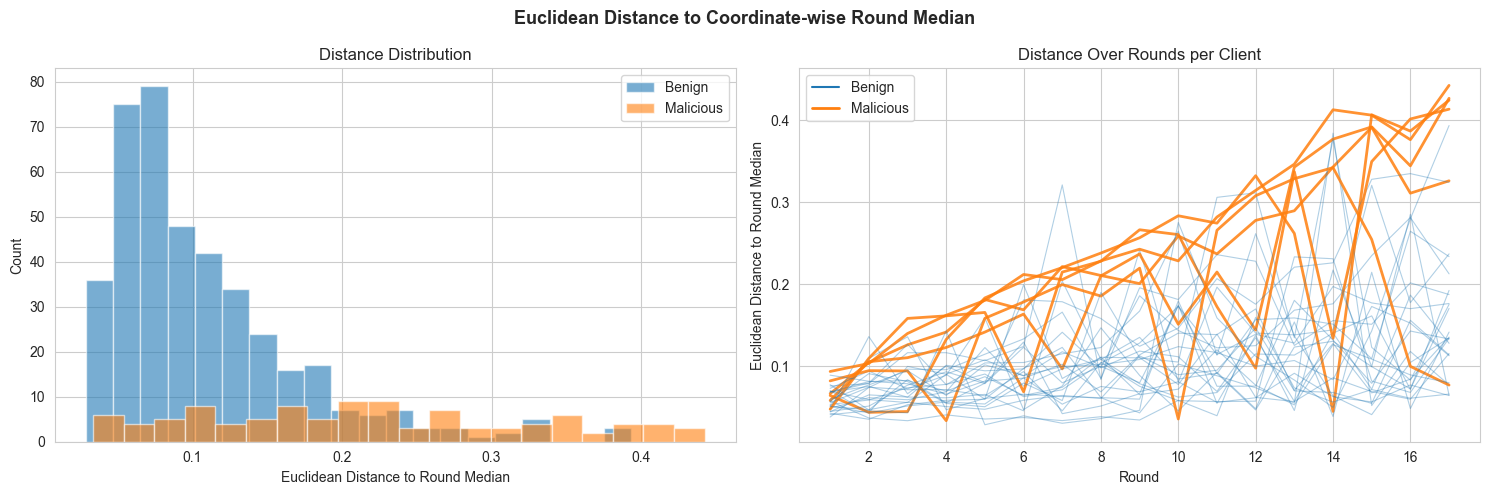

In [7]:
# ── Distribution + evolution over rounds ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram by ground-truth label
ax = axes[0]
for label, grp in df.groupby("is_malicious"):
    color = "tab:orange" if label else "tab:blue"
    name = "Malicious" if label else "Benign"
    ax.hist(
        grp["euclidean_distance"],
        bins=20,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor="white",
    )
ax.set_xlabel("Euclidean Distance to Round Median")
ax.set_ylabel("Count")
ax.set_title("Distance Distribution")
ax.legend()

# Right: score trajectory per client across rounds
ax = axes[1]
for cid, grp in df.groupby("client"):
    is_mal = grp["is_malicious"].iloc[0]
    color = "tab:orange" if is_mal else "tab:blue"
    alpha = 0.85 if is_mal else 0.35
    lw = 2.0 if is_mal else 0.8
    ax.plot(
        grp["round"], grp["euclidean_distance"], color=color, alpha=alpha, linewidth=lw
    )

legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=1.5, label="Benign"),
    Line2D([0], [0], color="tab:orange", linewidth=2.0, label="Malicious"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Round")
ax.set_ylabel("Euclidean Distance to Round Median")
ax.set_title("Distance Over Rounds per Client")

plt.suptitle(
    "Euclidean Distance to Coordinate-wise Round Median", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

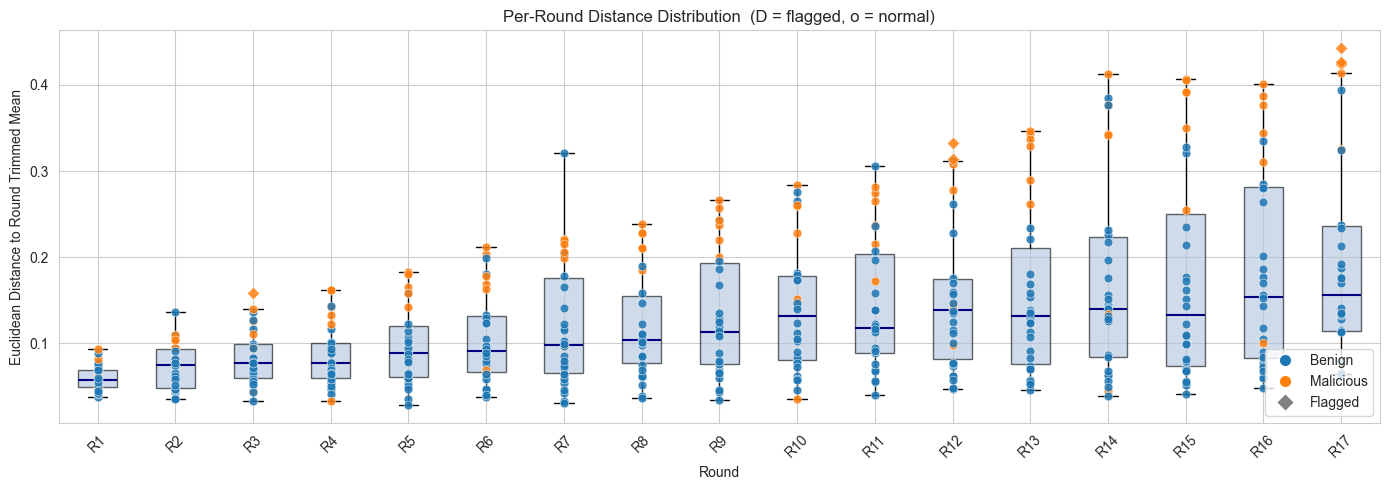

In [8]:
# ── Per-round box plot: score spread with flagged points highlighted ───────────
fig, ax = plt.subplots(figsize=(14, 5))

round_order = sorted(df["round"].unique())
positions = list(range(len(round_order)))
round_groups = [df[df["round"] == r]["euclidean_distance"].values for r in round_order]

bp = ax.boxplot(
    round_groups,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightsteelblue", alpha=0.6),
    medianprops=dict(color="navy", linewidth=1.5),
)

# Overlay individual points, coloured by ground truth
for pos, rnum in zip(positions, round_order):
    rdf = df[df["round"] == rnum]
    for _, row in rdf.iterrows():
        color = "tab:orange" if row["is_malicious"] else "tab:blue"
        marker = "D" if row["flagged"] else "o"
        zorder = 5 if row["flagged"] else 3
        ax.scatter(
            pos,
            row["euclidean_distance"],
            color=color,
            s=40,
            marker=marker,
            zorder=zorder,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
        )

ax.set_xticks(positions)
ax.set_xticklabels([f"R{r}" for r in round_order], rotation=45)
ax.set_xlabel("Round")
ax.set_ylabel("Euclidean Distance to Round Trimmed Mean")
ax.set_title("Per-Round Distance Distribution  (D = flagged, o = normal)")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:blue",
        markersize=9,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:orange",
        markersize=9,
        label="Malicious",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="grey",
        markersize=9,
        label="Flagged",
    ),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df["is_malicious"].astype(int)
y_pred = df["flagged"].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("=" * 40)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print("-" * 40)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 40)

  TP=6  FP=0  FN=96  TN=408
----------------------------------------
  Precision : 1.0000
  Recall    : 0.0588
  F1 Score  : 0.1111
